# Introdución á segmentación de imaxes con Python

A segmentación de imaxes é unha tarefa de visión por computador que consiste en clasificar cada píxel dunha imaxe en diferentes categorías. Neste caderno imos aprender os conceptos básicos da segmentación de imaxes usando Python e bibliotecas como OpenCV e scikit-image e PyTorch.

<center><img src="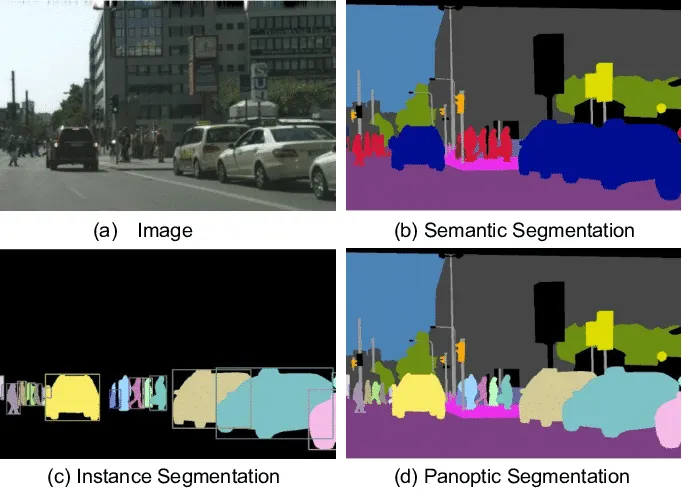
"/></center>

Como se pode ver na figura superior, existen principalmente tres tipos de segmentación:

1. Segmentación semántica: clasifica cada píxel da imaxe en categorías predefinidas, sen distinguir entre diferentes instancias da mesma categoría. Na subfigura (b), todos os píxeles pertencentes a coches teñen o mesmo valor (a mesma cor). O mesmo pasa coas persoas, as árbores, etc.
2. Segmentación de instancias: clasifica os píxeles pertencentes a diferentes instancias (obxectos) de interese nunha imaxe. Na subfigura (c), os obxectos de interese son os coches e as persoas. A diferencia da segmentación semántica, a segmentación de instancias si que diferencia os obxectos da mesma categoría, é dicir, cada coche e cada persoa teñen un valor diferente (unha cor diferente).
3. Segmentación panóptica: combina a segmentación semántica e a de instancias, proporcionando unha comprensión completa da escena. Todos os píxeles da imaxe son clasificados, tanto os que pertencen a obxectos de interese (coches e persoas) como os que non (árbores, estrada, etc.). Na subfigura (d), os píxeles pertencentes a coches e persoas teñen valores diferentes (cores diferentes), mentres que os píxeles pertencentes a outras categorías teñen o mesmo valor (a mesma cor).


Antes de nada imos instalar as librerías necesarias:

In [1]:
!pip install scikit-image scikit-learn matplotlib numpy plotly nbformat

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.8 MB 14.6 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.8 MB 15.6 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.8 MB 16.4 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 15.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2 [plotly]
   -------------------- ------------------- 1/2

## Segmentación mediante limiarización

A segmentación mediante limiarización é unha técnica sinxela e eficaz para separar obxectos de interese do fondo nunha imaxe. Consiste en definir un valor de limiar, e clasificar os píxeles da imaxe en función dese valor. Os píxeles cun valor superior ao limiar considéranse parte do obxecto de interese, mentres que os píxeles cun valor inferior considéranse parte do fondo. Pódense definir múltiples valores de limiar para segmentar diferentes obxectos ou rexións na imaxe.

Existen diferentes métodos para achar o valor de limiar óptimo, pero un dos máis empregados é o **método de Otsu**. Este método busca o valor de limiar que minimiza a varianza intra-clase, é dicir, a varianza dos píxeles dentro de cada clase (obxecto e fondo). O método de Otsu é especialmente útil cando a imaxe ten un histograma bimodal, onde os píxeles do obxecto e do fondo forman dous picos distintos.

A fórmula para calcular o valor de limiar óptimo segundo o método de Otsu é a seguinte:
$$k^* = \arg\min_k \left( \sigma^2_B(k) \right)$$
onde $k$ é o valor do limiar, e $\sigma^2_B(k)$ é a varianza inter-clase, que se define como:
$$\sigma^2_B(k) = \omega_0(k) \omega_1(k) \left( \mu_0(k) - \mu_1(k) \right)^2$$
onde:
- $\omega_0(k)$ e $\omega_1(k)$ son as probabilidades das dúas clases (obxecto e fondo) para un valor de limiar $k$.
- $\mu_0(k)$ e $\mu_1(k)$ son as medias das dúas clases para un valor de limiar $k$.

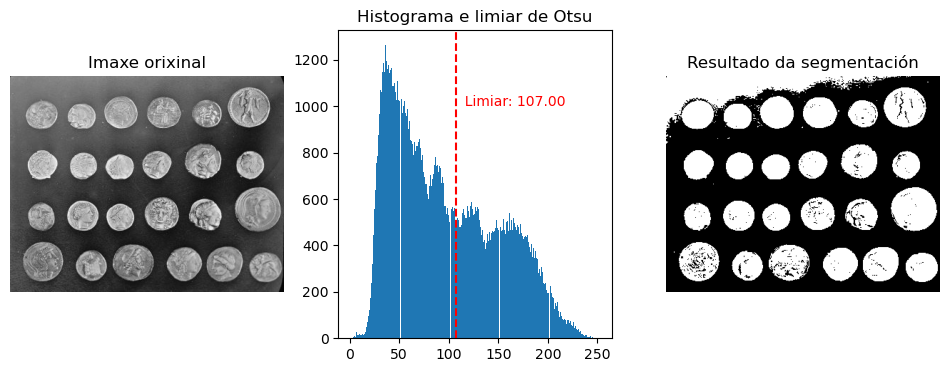

In [2]:
from skimage import data
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

# Cargamos unha imaxe de exemplo
image_coins = data.coins()

threshold = threshold_otsu(image_coins)
binary_mask = image_coins > threshold

# Amosamos a imaxe orixinal
_, ax = plt.subplots(ncols=3, figsize=(12, 4))

# Imaxe orixinal
ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Imaxe orixinal')
ax[0].axis('off')

# Histograma da imaxe
# A liña vertical vermella amosa onde Otsu colocou o limiar.
ax[1].hist(image_coins.ravel(), bins=256)
ax[1].axvline(threshold, color='r', linestyle='--')
ax[1].text(threshold, 1000, f'  Limiar: {threshold:.2f}', color='r', horizontalalignment='left')
ax[1].set_title('Histograma e limiar de Otsu')

# Imaxe segmentada (máscara)
ax[2].imshow(binary_mask, cmap=plt.cm.gray)
ax[2].set_title('Resultado da segmentación')
ax[2].axis('off')

plt.show()


ℹ️ Bótalle un ollo á función `try_all_threshold` do paquete `skimage.filters`, e próbaa coa imaxe anterior para ver como funcionan diferentes métodos de limiarización.

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


(<Figure size 1000x800 with 8 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Isodata'}>,
        <Axes: title={'center': 'Li'}>, <Axes: title={'center': 'Mean'}>,
        <Axes: title={'center': 'Minimum'}>,
        <Axes: title={'center': 'Otsu'}>,
        <Axes: title={'center': 'Triangle'}>,
        <Axes: title={'center': 'Yen'}>], dtype=object))

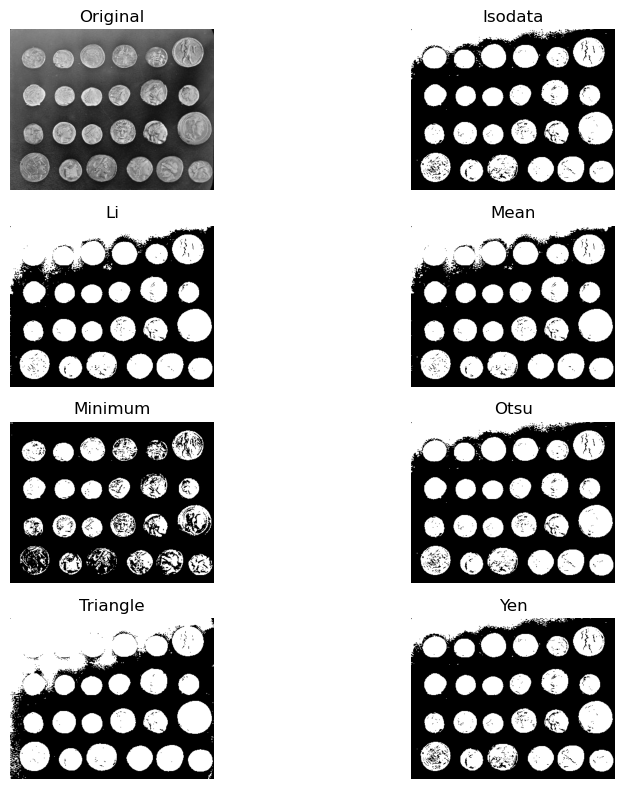

In [7]:
import skimage.filters
skimage.filters.try_all_threshold(image_coins, figsize=(10, 8))

Aínda que os métodos que traballan cun limiar global (o mesmo para todos os píxeles da imaxe) funcionan ben en moitos casos, para outras imaxes non son tan efectivos. Por exemplo:

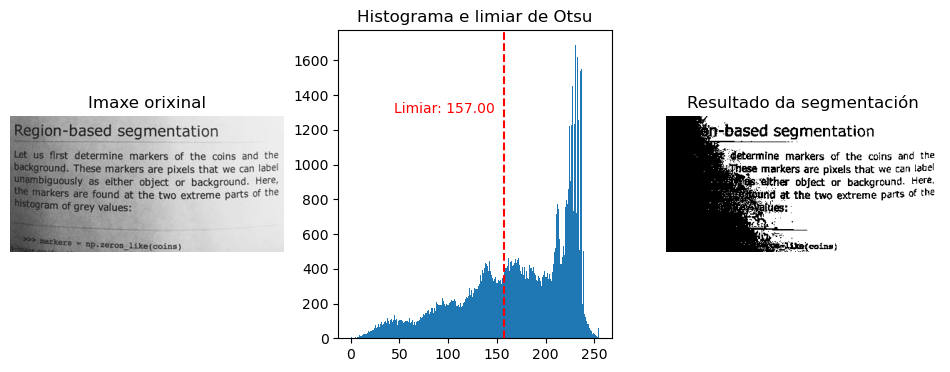

In [8]:
image_page = data.page()

threshold = threshold_otsu(image_page)
binary_mask = image_page > threshold

# Amosamos a imaxe orixinal
_, ax = plt.subplots(ncols=3, figsize=(12, 4))

# Imaxe orixinal
ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Imaxe orixinal')
ax[0].axis('off')

# Histograma da imaxe
# A liña vertical vermella amosa onde Otsu colocou o limiar.
ax[1].hist(image_page.ravel(), bins=256)
ax[1].axvline(threshold, color='r', linestyle='--')
ax[1].text(threshold, 1300, f'Limiar: {threshold:.2f}  ', color='r', horizontalalignment='right')
ax[1].set_title('Histograma e limiar de Otsu')

# Imaxe segmentada (máscara)
ax[2].imshow(binary_mask, cmap=plt.cm.gray)
ax[2].set_title('Resultado da segmentación')
ax[2].axis('off')

plt.show()

O problema radica en que parte do fondo (sobre todo na parte esquerda) ten unha intensidade similar á do texto. Isto pode deberse a unha iluminación desigual ou a sombras na imaxe orixinal. Nestes casos, pódese aplicar unha segmentación adaptativa, onde o valor do limiar varía segundo a rexión da imaxe.

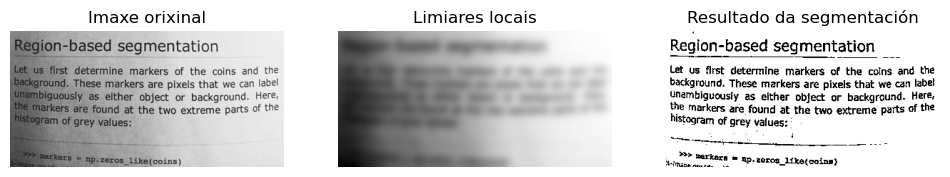

In [13]:
from skimage.filters import threshold_local

# Fixamos os parámetros para o limiar adaptativo
block_size = 35 # Tamaño da veciñanza, que se emprega para calcular o limiar local
offset = 10 # Valor que se resta ao limiar local para obter un limiar máis conservador

threshold = threshold_local(image_page, block_size=block_size, offset=offset)
binary_mask = image_page > threshold

# Amosamos a imaxe orixinal
_, ax = plt.subplots(ncols=3, figsize=(12, 4))

# Imaxe orixinal
ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Imaxe orixinal')
ax[0].axis('off')

# Mapa de limiares. Cada píxel deste mapa contén o limiar utilizado para segmentar dito píxel na imaxe orixinal.
ax[1].imshow(threshold, cmap=plt.cm.gray)
ax[1].set_title('Limiares locais')
ax[1].axis('off')

# Imaxe segmentada (máscara)
ax[2].imshow(binary_mask, cmap=plt.cm.gray)
ax[2].set_title('Resultado da segmentación')
ax[2].axis('off')

plt.show()

## Segmentación mediante o método das K-medias

O método das K-medias é un algoritmo de agrupamento non supervisado que se utiliza para segmentar imaxes en función das intensidades dos píxeles (é dicir, a cor). O obxectivo do algoritmo é dividir os píxeles da imaxe en K grupos (ou clusters) de tal forma que os píxeles dentro dun mesmo grupo sexan o máis similares posible entre si, e o máis diferentes posible dos píxeles doutros grupos.

O algoritmo das K-medias funciona do seguinte xeito:
1. Inicialización: Selecciónanse K centroides iniciais, que poden ser elixidos aleatoriamente ou mediante algún método específico.
2. Asignación: Cada píxel da imaxe é asignado ao centroide máis próximo, formando así K grupos.
3. Actualización: Calculanse os novos centroides como a media dos píxeles asignados a cada grupo.
4. Repetición: Os pasos 2 e 3 repítense ata que os centroides non cambien significativamente ou se alcance un número máximo de iteracións.

A función obxectivo do algoritmo das K-medias é minimizar a suma das distancias ao cadrado entre os píxeles e os seus respectivos centroides, o que se pode expresar matematicamente como:
$$J = \sum_{i=1}^{K} \sum_{x_j \in C_i} ||x_j - \mu_i||^2$$
onde:
- $K$ é o número de grupos.
- $C_i$ é o conxunto de píxeles asignados ao grupo $i$.
- $x_j$ é un píxel da imaxe.
- $\mu_i$ é o centroide do grupo $i$.
- $||x_j - \mu_i||^2$ é a distancia ao cadrado entre o píxel $x_j$ e o centroide $\mu_i$.

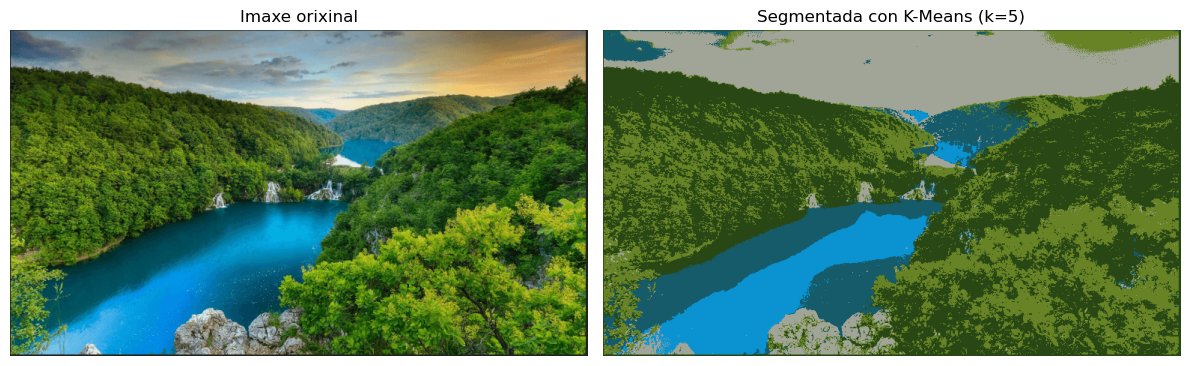

In [17]:
from sklearn.cluster import KMeans
from skimage.io import imread

# 1. Cargamos a imaxe da paisaxe (esta imaxe é en cor)
image_landscape = imread('https://github.com/tanvipenumudy/Winter-Internship-Internity/blob/main/Day%2011/Images/Notebook-2.PNG?raw=true')

# 2. Preparamos os datos para K-Means
# O algoritmo necesita unha lista de píxeles, non unha matriz 2D.
# "Aplanamos" a imaxe, pasando dunha matriz de dimensions (alto, ancho, 3) a outra matriz de dimensions (alto * ancho, 3)
pixels = image_landscape.reshape(-1, 3)

# 3. Aplicamos o algoritmo K-Medias
# Imos segmentar a imaxe en 3 rexións de cor
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(pixels)

# 4. Creamos a imaxe segmentada
# Obtemos as cores promedio de cada clúster (os centroides)
segmented_colors = kmeans.cluster_centers_.astype('uint8')
# A cada píxel orixinal asignamoslle a cor do clúster ao que pertence
segmented_image_data = segmented_colors[kmeans.labels_]
# Devolvemos a imaxe á súa forma orixinal (alto, ancho, 3)
segmented_image = segmented_image_data.reshape(image_landscape.shape)


# Visualizamos os resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imaxe orixinal
axes[0].imshow(image_landscape)
axes[0].set_title('Imaxe orixinal')
axes[0].axis('off')

# Imaxe segmentada
axes[1].imshow(segmented_image)
axes[1].set_title(f'Segmentada con K-Means (k={k})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Ahora imos representar os grupos mediante cores diferentes para visualizar a segmentación da imaxe.

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Reutilizamos os datos do K-Means do exemplo anterior
cluster_labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 1. Convertemos as cores dos centroides a formato RGB para Plotly
centroid_colors_int = centroids.astype(np.uint8)
centroid_colors_rgb_str = [f'rgb({c[0]}, {c[1]}, {c[2]})' for c in centroid_colors_int]

# Creamos a figura de Plotly (para que sexa interactiva)
fig = go.Figure()

# 2. Tomamos unha mostra aleatoria de píxeles
sample_indices = np.random.choice(pixels.shape[0], size=2000, replace=False)
sample_pixels = pixels[sample_indices]
sample_labels_for_plot = cluster_labels[sample_indices]

# 3. Engadimos a nube de puntos dos píxeles de mostra, coloreada por clúster
for i in range(k):
    cluster_pixels = sample_pixels[sample_labels_for_plot == i]
    
    fig.add_trace(go.Scatter3d(
        x=cluster_pixels[:, 0], 
        y=cluster_pixels[:, 1], 
        z=cluster_pixels[:, 2],
        mode='markers',
        marker=dict(
            size=2.5,
            color=centroid_colors_rgb_str[i],
            opacity=0.7
        ),
        name=f'Clúster {i}'
    ))

# 4. Engadimos os centroides como puntos grandes e destacados
fig.add_trace(go.Scatter3d(
    x=centroids[:, 0],
    y=centroids[:, 1],
    z=centroids[:, 2],
    mode='markers',
    marker=dict(
        size=8,
        color=centroid_colors_rgb_str,
        symbol='diamond',
        line=dict(color='black', width=2)
    ),
    name='Centroides'
))

# 5. Configuramos os títulos da figura e dos eixos e as marxes
fig.update_layout(
    title_text='Clústeres de K-Means no Espazo de Cor RGB',
    scene=dict(
        xaxis_title='Canle Vermella (R)',
        yaxis_title='Canle Verde (G)',
        zaxis_title='Canle Azul (B)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)

In [19]:
5

5

## Segmentación mediante o método GMM (Gaussian Mixture Model)

O método GMM é un algoritmo de agrupamento que asume que os datos son unha combinación de varias distribucións gaussianas. A idea principal é modelar a distribución dos píxeles da imaxe como unha combinación de múltiples distribucións gaussianas, cada unha representando un grupo ou rexión na imaxe.

O algoritmo GMM funciona do seguinte xeito:
1. Inicialización: selecciónanse os parámetros iniciais para as distribucións gaussianas (media, covarianza e peso).
2. Expectation-Maximization (EM): o algoritmo alterna entre dous pasos:
   - **Expectation (E-step)**: calcula a probabilidade de que cada píxel pertenza a cada unha das distribucións gaussianas.
   - **Maximization (M-step)**: actualiza os parámetros das distribucións gaussianas para maximizar a probabilidade dos datos observados.
3. Converxencia: os pasos E e M repítense ata que os parámetros non cambien significativamente ou se alcance un número máximo de iteracións.

A función obxectivo do algoritmo GMM é maximizar a verosimilitude dos datos observados, o que se pode expresar matematicamente como:
$$L = \sum_{j=1}^{N} \log \left( \sum_{i=1}^{K} \pi_i \mathcal{N}(x_j | \mu_i, \Sigma_i) \right)$$
onde:
- $N$ é o número total de píxeles.
- $K$ é o número de distribucións gaussianas.
- $\pi_i$ é o peso da distribución gaussiana $i$.
- $\mathcal{N}(x_j | \mu_i, \Sigma_i)$ é a función de densidade de probabilidade da distribución gaussiana $i$ para o píxel $x_j$.

O método GMM é especialmente útil para segmentar imaxes con múltiples rexións de cor ou textura, e pode adaptarse a formas complexas de distribución de datos.

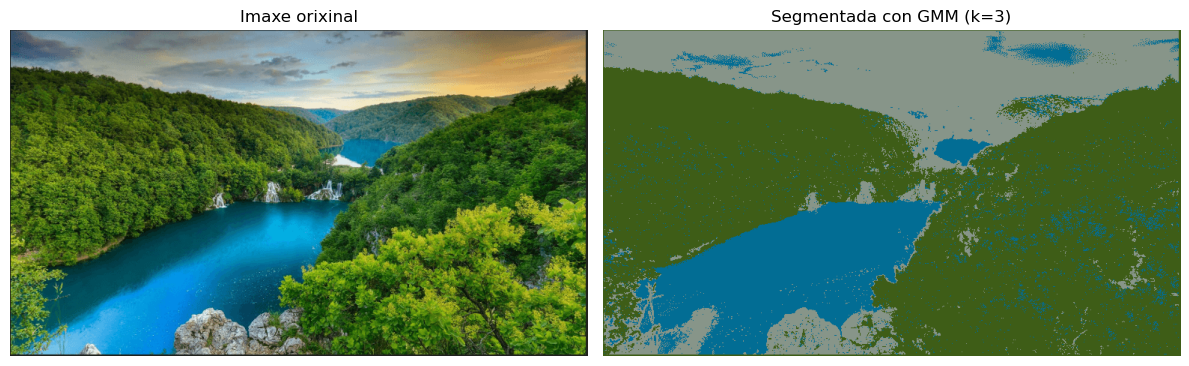

In [20]:
from sklearn.mixture import GaussianMixture

# 1. Preparamos os datos
# Ao igual que con K-Means, aplanamos a imaxe a unha lista de píxeles (puntos no espazo RGB)
pixels = image_landscape.reshape(-1, 3)

# 2. Aplicamos o algoritmo GMM
n_components = 3 # Número de compoñentes (clústeres)
n_init = 3 # Utilizamos 3 inicializacións diferentes para mellorar a converxencia
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42, n_init=n_init)
gmm.fit(pixels)

# 3. Predicimos o clúster para cada píxel
# O modelo dinos a que compoñente gaussiano é máis probable que pertenza cada píxel.
cluster_labels = gmm.predict(pixels)

# 4. Creamos a imaxe segmentada
# Substituímos cada píxel coa cor media do clúster ao que foi asignado.
# As cores medias dos clústeres son os 'means_' do modelo GMM.
segmented_colors = gmm.means_.astype(np.uint8)
segmented_image_data = segmented_colors[cluster_labels]

# 5. Volvemos a darlle a forma orixinal á imaxe
segmented_image = segmented_image_data.reshape(image_landscape.shape)

# 6. Visualizamos os resultados
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imaxe orixinal
axes[0].imshow(image_landscape)
axes[0].set_title('Imaxe orixinal')
axes[0].axis('off')

# Imaxe segmentada
axes[1].imshow(segmented_image)
axes[1].set_title(f'Segmentada con GMM (k={n_components})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Ahora imos representar as distribucións gaussianas axustadas aos datos.

In [21]:
# Convertemos a cor media de cada compoñente a cadeas de texto "rgb(r,g,b)".
mean_colors_rgb_str = [f'rgb({c[0]}, {c[1]}, {c[2]})' for c in segmented_colors]

# Crearmos a figura de Plotly (interactiva)
fig = go.Figure()

# Tomamos unha mostra aleatoria de píxeles
sample_indices = np.random.choice(pixels.shape[0], size=2000, replace=False)
sample_pixels = pixels[sample_indices]
sample_labels = cluster_labels[sample_indices]

# Engadimos a nube de puntos dos píxeles de mostra á figura
for i in range(gmm.n_components):
    cluster_pixels = sample_pixels[sample_labels == i]
    fig.add_trace(go.Scatter3d(
        x=cluster_pixels[:, 0], 
        y=cluster_pixels[:, 1], 
        z=cluster_pixels[:, 2],
        mode='markers',
        marker=dict(
            size=2.5,
            color=mean_colors_rgb_str[i],
            opacity=0.7
        ),
        name=f'Compoñente {i}'
    ))
    
# Debuxamos os elipsoides 3D
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

for i in range(gmm.n_components):
    mean = gmm.means_[i]
    covariance = gmm.covariances_[i]
    
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    radii = 2 * np.sqrt(eigenvalues)
    transform = eigenvectors @ np.diag(radii)
    
    x_ellipsoid, y_ellipsoid, z_ellipsoid = transform @ [x_sphere.flatten(), y_sphere.flatten(), z_sphere.flatten()]
    x_ellipsoid += mean[0]
    y_ellipsoid += mean[1]
    z_ellipsoid += mean[2]
    
    fig.add_trace(go.Surface(
        x=x_ellipsoid.reshape(x_sphere.shape),
        y=y_ellipsoid.reshape(y_sphere.shape),
        z=z_ellipsoid.reshape(z_sphere.shape),
        colorscale=[[0, mean_colors_rgb_str[i]], [1, mean_colors_rgb_str[i]]],
        opacity=0.2,
        showscale=False,
        name=f'Gaussiana {i}',
        hoverinfo='none'
    ))

# Configuración final do deseño do gráfico
fig.update_layout(
    title_text='Distribucións gaussianas en 3D no espazo RGB',
    scene=dict(
        xaxis_title='Canle vermella (R)',
        yaxis_title='Canle verde (G)',
        zaxis_title='Canle azul (B)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# Exercicio proposto

A continuación proponse utilizar o dataset FruitSeg30 para realizar tarefas de segmentación en imaxes de frutas. Primeiro descargamos e descomprimimos o dataset co código seguinte:

In [22]:
from pathlib import Path
import zipfile
import urllib.request

url = 'https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/vkht8pfsp3-3.zip'
dataset_name = Path('FruitSeg30_Segmentation Dataset & Mask Annotations')
output_zip_path = Path('FruitSeg30.zip')
output_dir = Path('FruitSeg30')

if not output_dir.is_dir():
    urllib.request.urlretrieve(url, output_zip_path)
    with zipfile.ZipFile(output_zip_path, 'r') as zip_ref:
        zip_ref.extractall()

    (dataset_name/output_dir).rename(output_dir)

    output_zip_path.unlink()
    dataset_name.rmdir()

Fíxate que se crea un cartafol chamado `FruitSeg30`, que contén 30 categorías de froitas. En cada categoría hai dous subcartafoles: `images`, que contén as imaxes das froitas, e `masks`, que contén as máscaras de segmentación reais, as que esperamos obter cos nosos métodos de segmentación. É o que se coñece como *ground truth*. A continuación amósase un exemplo dunha imaxe e a súa máscara correspondente:

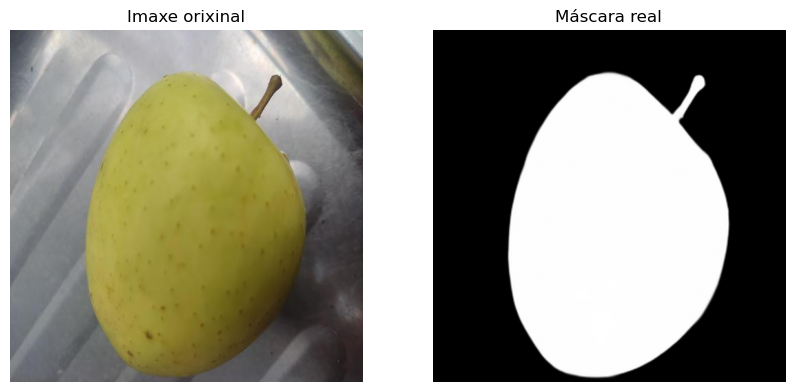

In [23]:
category_name = output_dir / "Apple_Golden Delicious"
img_id = 1

original_image = imread(category_name / "Images" / f"{img_id}.jpg")
mask_image = imread(category_name / "Mask" / f"{img_id}_mask.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_image)
axes[0].set_title("Imaxe orixinal")
axes[0].axis('off')
axes[1].imshow(mask_image, cmap="gray")
axes[1].set_title("Máscara real")
axes[1].axis('off')
plt.show()

1. Empeza cunha categoría sinxela, por exemplo `Avocado`. Carga unha imaxe desta categoría e proba a segmentala utilizando os tres métodos vistos: limiarización, K-medias e GMM. Compara os resultados obtidos de forma cualitativa (a ollo). Podes representar graficamente a imaxe orixinal, a máscara real e as máscaras obtidas cos diferentes métodos de segmentación para facilitar a comparativa.
2. Selecciona ahora unha categoría máis complexa, por exemplo `Grape`. Repite o proceso anterior e compara os resultados obtidos. Tiveches que facer algunha modificación na execución dos métodos para adaptalos a esta nova categoría? É posible segmentar por separado a uva, a súa sombra e o fondo?
3. Aproveitando que temos o *ground truth*, agora intenta cuantificar a calidade das segmentacións obtidas. Para elo utiliza a métrica simple do *accuracy* (a porcentaxe de píxeles correctamente clasificados). Recorda que o obxectivo do problema é realizar unha clasificación binaria, polo que se nalgún dataset precisas facer unha segmentación en máis categorías debes converter a máscara resultante a unha máscara binaria onde a parte da froita estea representada en branco e o resto estea representado en negro. Selecciona un grupo de categorías (polo menos 5) e un mínimo de 10 imaxes de cada categoría e calcula o *accuracy* medio para cada método e cada categoría. Que método obtén mellores resultados de forma xeral? Hai moita diferencia entre os resultados nas diferentes categorías?

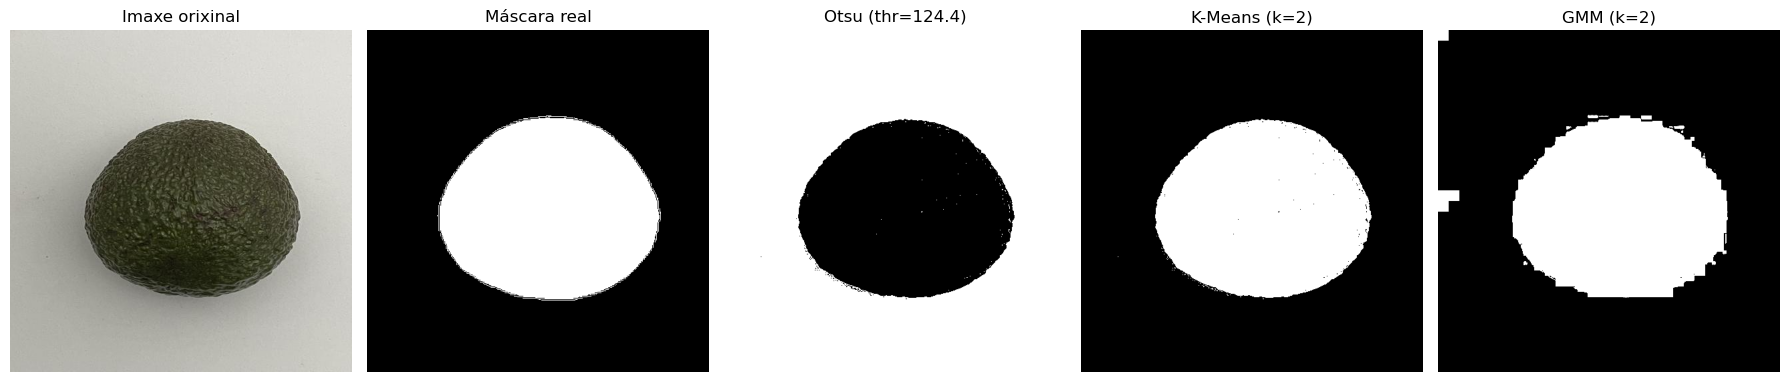

In [29]:
# Empezamos coa categoría "Avocado" e segmentamos coa tríada: limiarización (Otsu), K-Means e GMM.
category_name = output_dir / "Avocado"
img_id = 1

# Cargamos imaxe e máscara (seguindo o formato usado antes)
original_image = imread(category_name / "Images" / f"{img_id}.jpg")
mask_image = imread(category_name / "Mask" / f"{img_id}_mask.png")

# Convertimos máscara real a binaria (pode ser single/3-channel)
if mask_image.ndim == 3:
    mask_true = mask_image.mean(axis=2) > 0
else:
    mask_true = mask_image > 0

# 1) Limiarización (Otsu) sobre canle de luminancia
lum = (0.299 * original_image[..., 0] +
       0.587 * original_image[..., 1] +
       0.114 * original_image[..., 2])
otsu_val = threshold_otsu(lum)
mask_otsu = lum > otsu_val

# 2) K-Means (2 clusters). Escollemos o label que máis se solapa coa máscara real.
pixels = original_image.reshape(-1, 3).astype(np.float32)
kmeans_model = KMeans(n_clusters=2, random_state=0, n_init=10)
labels_km = kmeans_model.fit_predict(pixels)
labels_km_img = labels_km.reshape(original_image.shape[:2])

# Determinar qué label corresponde á froita (máis overlap coa máscara real)
flat_true = mask_true.ravel()
overlaps = [np.sum((labels_km == i) & flat_true) for i in range(2)]
fruit_label_km = int(np.argmax(overlaps))
mask_km = labels_km_img == fruit_label_km

# 3) GMM (2 compoñentes), mesma estratexia para seleccionar compoñente da froita
pixels_float = pixels.astype(np.float64)
gmm_model = GaussianMixture(n_components=2, covariance_type='full', random_state=0, n_init=3, max_iter=200)
gmm_labels = gmm_model.fit_predict(pixels_float)

gmm_labels_img = gmm_labels.reshape(original_image.shape[:2])
overlaps_gmm = [np.sum((gmm_labels == i) & flat_true) for i in range(2)]
fruit_label_gmm = int(np.argmax(overlaps_gmm))
mask_gmm = gmm_labels_img == fruit_label_gmm

# Visualización comparativa
fig, axs = plt.subplots(1, 5, figsize=(18, 5))
axs[0].imshow(original_image); axs[0].set_title("Imaxe orixinal"); axs[0].axis('off')
axs[1].imshow(mask_true, cmap='gray'); axs[1].set_title("Máscara real"); axs[1].axis('off')
axs[2].imshow(mask_otsu, cmap='gray'); axs[2].set_title(f'Otsu (thr={otsu_val:.1f})'); axs[2].axis('off')
axs[3].imshow(mask_km, cmap='gray'); axs[3].set_title("K-Means (k=2)"); axs[3].axis('off')
axs[4].imshow(mask_gmm, cmap='gray'); axs[4].set_title("GMM (k=2)"); axs[4].axis('off')
plt.tight_layout()
plt.show()

Otsu acc: 0.0157 | KMeans k=2 acc: 0.9838 | KMeans k=3 acc: 0.8589
GMM k=2 acc: 0.9913 | GMM k=3 acc: 0.9913


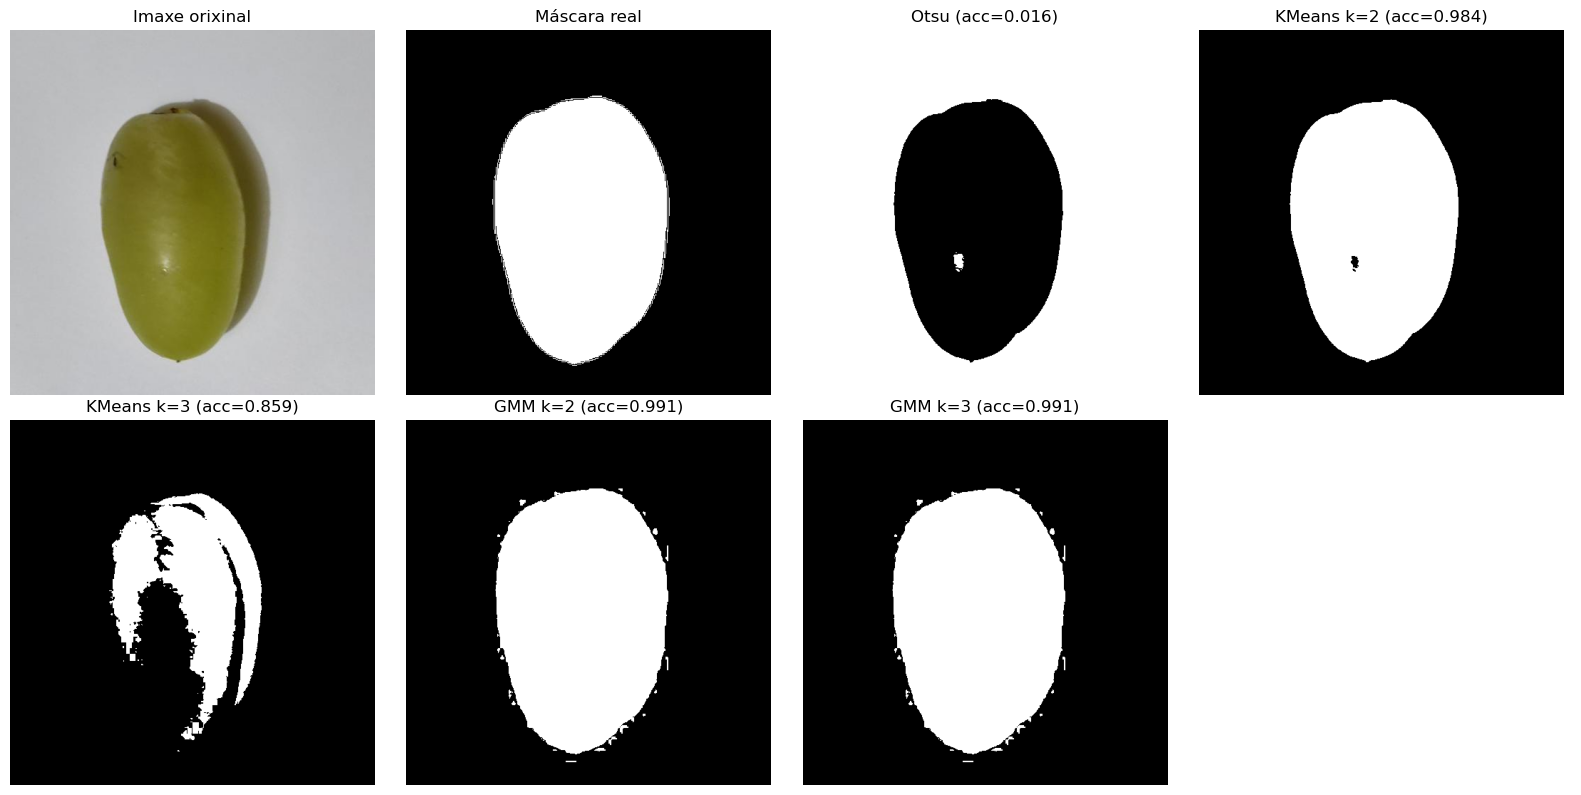

In [ ]:
# 2) Selección dunha categoría máis complexa: Grape. Repetimos Otsu, KMeans (k=2,3) e GMM (k=2,3) e comparamos resultados e accuracy.
category_name = output_dir / "Grape"
img_id = 1

# Cargamos imaxe e máscara
original_image = imread(category_name / "Images" / f"{img_id}.jpg")
mask_image = imread(category_name / "Mask" / f"{img_id}_mask.png")

# Normalizamos a máscara a binaria
if mask_image.ndim == 3:
    mask_true = mask_image.mean(axis=2) > 0
else:
    mask_true = mask_image > 0

# Preparamos píxeles e luminancia
pixels = original_image.reshape(-1, 3).astype(np.float32)
lum = (0.299 * original_image[..., 0] + 0.587 * original_image[..., 1] + 0.114 * original_image[..., 2])

# Otsu sobre luminancia
otsu_val = threshold_otsu(lum)
mask_otsu = lum > otsu_val

# KMeans k=2 (binarización por cor)
km2 = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_km2 = km2.fit_predict(pixels)
labels_km2_img = labels_km2.reshape(original_image.shape[:2])
overlaps_km2 = [np.sum((labels_km2 == i) & mask_true.ravel()) for i in range(2)]
fruit_label_km2 = int(np.argmax(overlaps_km2))
mask_km2 = labels_km2_img == fruit_label_km2

# KMeans k=3 (intento de separar sombra como terceiro cluster)
km3 = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_km3 = km3.fit_predict(pixels)
labels_km3_img = labels_km3.reshape(original_image.shape[:2])
overlaps_km3 = [np.sum((labels_km3 == i) & mask_true.ravel()) for i in range(3)]
fruit_label_km3 = int(np.argmax(overlaps_km3))
mask_km3 = labels_km3_img == fruit_label_km3

# Helper para axustar GMM de forma robusta e obter etiquetas
def fit_gmm_labels(pixels_arr, n_components):
    pixels64 = pixels_arr.astype(np.float64)
    try:
        gm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=0, n_init=3, max_iter=200)
        labels = gm.fit_predict(pixels64)
    except TypeError:
        # Versións máis antigas de sklearn non teñen n_init en GaussianMixture
        gm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=0, max_iter=200)
        labels = gm.fit_predict(pixels64)
    except Exception as e:
        print('Advertencia: GMM non se axustou correctamente, usando KMeans como fallback. Erro:', e)
        labels = km2.labels_ if n_components == 2 else km3.labels_
    return labels

# GMM con 2 e 3 compoñentes
labels_gmm2 = fit_gmm_labels(pixels, 3)
labels_gmm2_img = labels_gmm2.reshape(original_image.shape[:2])
overlaps_gmm2 = [np.sum((labels_gmm2 == i) & mask_true.ravel()) for i in range(2)]
fruit_label_gmm2 = int(np.argmax(overlaps_gmm2))
mask_gmm2 = labels_gmm2_img == fruit_label_gmm2

labels_gmm3 = fit_gmm_labels(pixels, 3)
labels_gmm3_img = labels_gmm3.reshape(original_image.shape[:2])
overlaps_gmm3 = [np.sum((labels_gmm3 == i) & mask_true.ravel()) for i in range(3)]
fruit_label_gmm3 = int(np.argmax(overlaps_gmm3))
mask_gmm3 = labels_gmm3_img == fruit_label_gmm3

# Métrica simple: accuracy pixeles
def accuracy(pred, true):
    return np.mean((pred == true))

acc_otsu = accuracy(mask_otsu, mask_true)
acc_km2 = accuracy(mask_km2, mask_true)
acc_km3 = accuracy(mask_km3, mask_true)
acc_gmm2 = accuracy(mask_gmm2, mask_true)
acc_gmm3 = accuracy(mask_gmm3, mask_true)

print(f'Otsu acc: {acc_otsu:.4f} | KMeans k=2 acc: {acc_km2:.4f} | KMeans k=3 acc: {acc_km3:.4f}')
print(f'GMM k=2 acc: {acc_gmm2:.4f} | GMM k=3 acc: {acc_gmm3:.4f}')

# Visualización comparativa
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs[0,0].imshow(original_image); axs[0,0].set_title('Imaxe orixinal'); axs[0,0].axis('off')
axs[0,1].imshow(mask_true, cmap='gray'); axs[0,1].set_title('Máscara real'); axs[0,1].axis('off')
axs[0,2].imshow(mask_otsu, cmap='gray'); axs[0,2].set_title(f'Otsu (acc={acc_otsu:.3f})'); axs[0,2].axis('off')
axs[0,3].imshow(mask_km2, cmap='gray'); axs[0,3].set_title(f'KMeans k=2 (acc={acc_km2:.3f})'); axs[0,3].axis('off')
axs[1,0].imshow(mask_km3, cmap='gray'); axs[1,0].set_title(f'KMeans k=3 (acc={acc_km3:.3f})'); axs[1,0].axis('off')
axs[1,1].imshow(mask_gmm2, cmap='gray'); axs[1,1].set_title(f'GMM k=2 (acc={acc_gmm2:.3f})'); axs[1,1].axis('off')
axs[1,2].imshow(mask_gmm3, cmap='gray'); axs[1,2].set_title(f'GMM k=3 (acc={acc_gmm3:.3f})'); axs[1,2].axis('off')
axs[1,3].axis('off')
plt.tight_layout()
plt.show()